<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Assignments/Assignment_Quiz/PCA_Assignment_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement:**

You have been provided with a multi dimensional data that contains information on certain images. Using machine learning, you should be able to predict the images on the new set of data using the model that you have trained on the existing data.



**Dataset Information:**

Each point in the data is an 8×8 image.

|                       |                  |
|-----------------------|------------------|
| Classes               | 10               |
| Samples per class     | ~180             |
| Samples total         | 1797             |
| Dimensionality        | 64               |
| Features              | integers 0-16    |

**Note: Load the dataset from sklearn.datasets.load_digits()**



**STEPS to perform PCA:**
1. Standardize the data
2. Compute the covariance matrix
3. Compute eigen values and eigen vector
4. Sort the eigen values
5. calculate variance explained and cumulative variance
6. select number of Principle Components
7. Interpret the data

1) PCA is ________?
- None of the above
- Semisupervised
- Unsupervised
- Supervised

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_digits

In [4]:
digits=load_digits()  #loading the data

* **PCA (Principal Component Analysis)** → focuses on finding directions (principal components) that capture **maximum variance** in the data, without considering class labels.
* **LDA (Linear Discriminant Analysis)** → a **supervised** technique that finds directions (linear discriminants) which maximize **class separability** (i.e., maximize the distance between classes and minimize variance within a class).

👉 In short:

* PCA → variance (unsupervised)
* LDA → class separability (supervised)


PCA is based on **eigen decomposition** of the covariance matrix of the data. Here’s the flow:

1. **Center the data** → subtract the mean from each feature.
2. **Compute the covariance matrix** of the centered data.
3. **Find eigenvalues and eigenvectors** of this covariance matrix.

   * **Eigenvalues** → tell you how much variance is captured in that direction.
   * **Eigenvectors** → give you the directions of the new axes (principal components).
4. **Sort eigenvectors** by descending eigenvalues → pick the top-k eigenvectors to form the new feature space.

So:

* **Eigenvectors = directions (principal components)**
* **Eigenvalues = amount of variance explained**

👉 PCA = projection of data onto the space spanned by the top eigenvectors.



If you have a data matrix (X) of size (n \times d):

* (n) = number of samples (rows)
* (d) = number of features (columns)

PCA usually works on the **covariance matrix**:

[
\Sigma = \frac{1}{n-1} X^T X
]

This covariance matrix has size (d \times d).

👉 For a (d \times d) matrix:

* There are **d eigenvalues** (some may be zero or repeated).
* Correspondingly, there are up to **d eigenvectors**.

So:

* If your dataset has **100 features**, you can get up to **100 eigenvectors** (principal components).
* But in practice, you usually select the **top k eigenvectors** that explain most of the variance.

⚡ Also note: the number of **nonzero eigenvalues** is at most `(min(n-1, d))`, since rank is limited by samples too.


When we do PCA:

1. We compute the **covariance matrix** of the data.

   * Its eigenvalues $(\lambda_i)$ tell us **how much variance** is along each eigenvector (principal component).

2. To find the **percentage of variance explained** by each component:

$
\text{Explained Variance Ratio for component i} = \frac{\lambda_i}{\sum_j \lambda_j}
$

where $\sum_j \lambda_j$ is the **total variance** in the data.

---

In our example:

* Eigenvalues = ([2.0, 2.67])
* Total variance = (2.0 + 2.67 = 4.67)

So:

* PC1: (2.0 / 4.67 \approx 0.4286 ) → **42.9%**
* PC2: (2.67 / 4.67 \approx 0.5714 ) → **57.1%**

Add them up → (42.9% + 57.1% = 100%). ✅

---

👉 That’s why the **eigenvalues** are the key to understanding how much information (variance) each principal component carries.

1. Answer - Unsupervised

2) Why is PCA needed in the Data Science field?
- Data Visualization
- All of the Above
- In Dimensionality Reduction
- Data Manipulation

Data Visualization:

Here’s how **PCA helps in Data Visualization**:

* If you have **high-dimensional data** (say 10, 50, or 100 features), you can’t plot it directly.
* PCA reduces it to **2D or 3D** by projecting data onto the **top 2 or 3 principal components**.
* These components capture the **maximum variance** → so when you plot them, you’re seeing the “most informative view” of the data.

👉 Even if your data is already **2D**, PCA can still help:

* It rotates the axes into directions of **maximum variance**, which can sometimes make clusters or patterns more visible.
* For example, instead of plotting on raw features (which might be correlated or noisy), plotting on PCs gives a clearer picture.

So yes — **PCA visualization = reducing to 2D/3D to visually capture variance structure**.

The correct answer is:

**All of the Above ✅**

Because PCA is used for multiple purposes in Data Science:

* **Dimensionality Reduction** → Reduce many features into fewer while keeping most of the variance.
* **Data Visualization** → Helps plot high-dimensional data in 2D or 3D.
* **Data Manipulation / Preprocessing** → Removes multicollinearity, noise, and makes models more efficient.

👉 So PCA is not limited to one use-case; that’s why the best choice is **All of the Above**.


2. Answer - All of the Above

3) Extract only features and scale the data using StandardScaler() , compute min covariance?
- 0.1
- -1
- -0.57
- None of the above

In [6]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [7]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [8]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [9]:
digits.data.shape

(1797, 64)

In [10]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

In [14]:
digits.target.shape

(1797,)

In [13]:
np.unique(digits.target)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

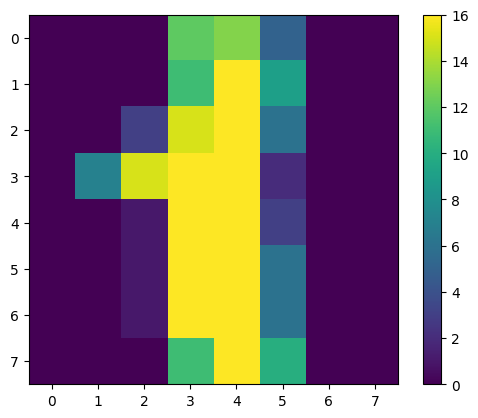

In [16]:
plt.imshow(digits.images[1])
#.imshow: display image, converts numerical data into pixel/image format
#[1]: represents the second image(index 1)
plt.colorbar()

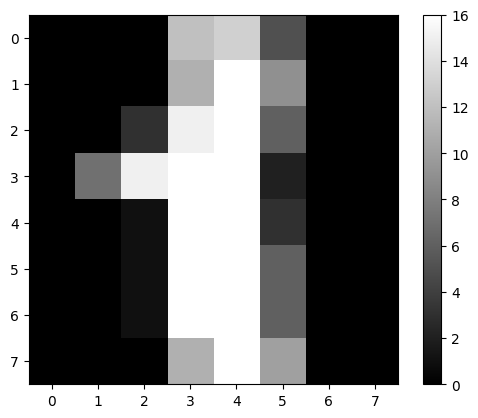

In [15]:
plt.imshow(digits.images[1],cmap=plt.cm.gray)
#.imshow: display image, converts numerical data into pixel/image format
#[1]: represents the second image(index 1)
plt.colorbar() # the bar in the side

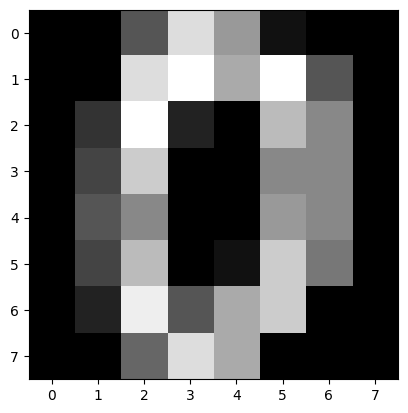

In [17]:
plt.imshow(digits.images[0],cmap=plt.cm.gray)

In [18]:
X_digits = pd.DataFrame(digits.data)

In [19]:
X_digits

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [20]:
y_digits = pd.Series(digits.target)

In [21]:
y_digits

,0
0,0
1,1
2,2
3,3
4,4
...,...
1792,9
1793,0
1794,8
1795,9


In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
#Standardization : scaling down the data in a way where mean=0, std dev=1

In [24]:
sc_digits = StandardScaler()

In [25]:
X_digits_std=sc_digits.fit_transform(X_digits)
X_digits_std

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

In [26]:
X_digits_std.shape

(1797, 64)

[Numpy cov documentation](https://numpy.org/doc/2.1/reference/generated/numpy.cov.html)

rowvarbool, optional

If rowvar is True (default), then each row represents a variable, with observations in the columns. Otherwise, the relationship is transposed: each column represents a variable, while the rows contain observations.



In [28]:
#Transpose : convert rows to columns
#we take transpose because np.cov expects rows as features.
X_digits_std_T=X_digits_std.T

In [29]:
X_digits_std_T

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.33501649, -0.33501649, -0.33501649, ..., -0.33501649,
        -0.33501649, -0.33501649],
       [-0.04308102, -1.09493684, -1.09493684, ..., -0.88456568,
        -0.67419451,  1.00877481],
       ...,
       [-1.14664746,  0.54856067,  1.56568555, ..., -0.12952258,
         0.8876023 ,  0.8876023 ],
       [-0.5056698 , -0.5056698 ,  1.6951369 , ..., -0.5056698 ,
        -0.5056698 , -0.26113572],
       [-0.19600752, -0.19600752, -0.19600752, ..., -0.19600752,
        -0.19600752, -0.19600752]])

In [30]:
X_digits_std.shape

(1797, 64)

In [31]:
X_digits_std_T.shape

(64, 1797)

In [32]:
np.cov(X_digits_std_T)

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.00055679,  0.55692803, ..., -0.02988686,
         0.02656195, -0.04391324],
       [ 0.        ,  0.55692803,  1.00055679, ..., -0.04120565,
         0.07263924,  0.08256908],
       ...,
       [ 0.        , -0.02988686, -0.04120565, ...,  1.00055679,
         0.64868875,  0.26213704],
       [ 0.        ,  0.02656195,  0.07263924, ...,  0.64868875,
         1.00055679,  0.62077355],
       [ 0.        , -0.04391324,  0.08256908, ...,  0.26213704,
         0.62077355,  1.00055679]])

In [34]:
np.cov(X_digits_std_T).shape

(64, 64)

In [33]:
# we can do without transposing ourself if we pass rowvar=False
np.cov(X_digits_std, rowvar=False)

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.00055679,  0.55692803, ..., -0.02988686,
         0.02656195, -0.04391324],
       [ 0.        ,  0.55692803,  1.00055679, ..., -0.04120565,
         0.07263924,  0.08256908],
       ...,
       [ 0.        , -0.02988686, -0.04120565, ...,  1.00055679,
         0.64868875,  0.26213704],
       [ 0.        ,  0.02656195,  0.07263924, ...,  0.64868875,
         1.00055679,  0.62077355],
       [ 0.        , -0.04391324,  0.08256908, ...,  0.26213704,
         0.62077355,  1.00055679]])

In [35]:
np.cov(X_digits_std, rowvar=False).shape

(64, 64)

In [38]:
np.equal(np.cov(X_digits_std_T), np.cov(X_digits_std, rowvar=False))

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [37]:
np.equal(np.cov(X_digits_std_T), np.cov(X_digits_std, rowvar=False)).all()

np.True_

In [39]:
np.array_equal(np.cov(X_digits_std_T), np.cov(X_digits_std, rowvar=False))

True

In [40]:
cov_mat_digits = np.cov(X_digits_std, rowvar=False)

In [41]:
np.dot([1, 2, 3], [7, 8, 9]) # 7 + 16 + 27

np.int64(50)

In Python (NumPy), **`dot()`, `@`, and `matmul()`** are all related to matrix multiplication, but there are subtle differences. Let’s break it down clearly:

---

##### 1️⃣ `@` operator

* Introduced in **Python 3.5** for **matrix multiplication**.
* For 2D arrays: exactly the same as `np.matmul`.
* For 1D arrays: behaves like **dot product**.

```python
import numpy as np
A = np.array([[1,2],[3,4]])
B = np.array([[5,6],[7,8]])

C = A @ B  # matrix multiplication
```

---

##### 2️⃣ `np.matmul()`

* Function version of `@`.
* For **2D arrays** → matrix multiplication
* For **higher dimensions** (3D+) → performs **stacked matrix multiplication** along the last two axes.
* Can handle **batched matrices**.

```python
C = np.matmul(A, B)  # same as A @ B
```

---

##### 3️⃣ `np.dot()`

* Older function, slightly different rules:

  * **1D arrays** → dot product
  * **2D arrays** → matrix multiplication
  * **N-D arrays (N>2)** → sum product over the **last axis of first array and second-to-last of second array**
* Does **not support broadcasting** for batches like `matmul`.

```python
C = np.dot(A, B)  # same as A @ B for 2D arrays
```

---

##### ✅ Key Summary Table

| Function | 1D arrays | 2D arrays  | ND arrays >2D   | Supports batch? |
| -------- | --------- | ---------- | --------------- | --------------- |
| `@`      | dot       | matrix mul | yes             | yes             |
| `matmul` | dot       | matrix mul | yes             | yes             |
| `dot`    | dot       | matrix mul | different rules | no              |

---

💡 **For PCA covariance calculation:**

```python
cov_matrix = (X_digits_std.T @ X_digits_std) / (n_samples - 1)
```

* Using `@`, `np.matmul()`, or `np.dot()` **all work the same** because `X_centered` is 2D.

---


In [42]:
# we can compute manually and check

n_samples_digits = X_digits_std.shape[0]  # to get number of rows
cov_mat_digits_manual = (X_digits_std.T @ X_digits_std) / (n_samples_digits - 1)
print(cov_mat_digits_manual)


[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          1.00055679  0.55692803 ... -0.02988686  0.02656195
  -0.04391324]
 [ 0.          0.55692803  1.00055679 ... -0.04120565  0.07263924
   0.08256908]
 ...
 [ 0.         -0.02988686 -0.04120565 ...  1.00055679  0.64868875
   0.26213704]
 [ 0.          0.02656195  0.07263924 ...  0.64868875  1.00055679
   0.62077355]
 [ 0.         -0.04391324  0.08256908 ...  0.26213704  0.62077355
   1.00055679]]


In [44]:
cov_mat_digits_manual.shape

(64, 64)

In [43]:
np.array_equal(cov_mat_digits, cov_mat_digits_manual)

False

In [45]:
np.allclose(cov_mat_digits, cov_mat_digits_manual)
# True

True

The reason `np.array_equal` returns **False** is **not because the math is wrong**, but because **`np.cov` does some internal centering and numerical differences**, plus potential differences in how the division is done when you pass `X` already standardized. Let me explain carefully:

---

### 1️⃣ What you did manually

```python
cov_mat_digits_manual = (X_digits_std.T @ X_digits_std) / (n_samples_digits - 1)
```

* `X_digits_std` is **already standardized** (mean 0, std 1).
* You directly applied `X.T @ X / (n-1)`. ✅
* This gives **sample covariance** of your standardized data.

---

### 2️⃣ What `np.cov` does

```python
cov_mat_digits = np.cov(X_digits_std, rowvar=False)
```

* By default, `np.cov` **subtracts the mean again** before computing covariance:

$
\text{np.cov}(X) = \frac{(X - X_{\text{mean}})^T (X - X_{\text{mean}})}{n-1}
$

* Even though `X_digits_std` has mean ≈ 0, due to **floating point precision**, the centering introduces tiny differences.

---

### 3️⃣ Why `np.array_equal` returns False

* `np.array_equal` checks for **exact equality of floating-point numbers**.
* Small rounding differences from centering or numerical precision make it **not exactly equal**.

✅ But if you check with `np.allclose`, it will be **practically equal**:

```python
np.allclose(cov_mat_digits, cov_mat_digits_manual)
# True
```

---

### TL;DR

* `False` occurs because **tiny floating-point differences**, not a wrong calculation.
* Always use `np.allclose` when comparing floating-point matrices.

---


**`np.allclose(A, B)`** is a NumPy function that checks if **all elements of two arrays are “close enough”**, allowing for tiny floating-point differences.

---

##### Why we need it

* Computers store decimal numbers approximately.
* Two calculations that should be mathematically equal may differ in the **last few decimal places**.
* `np.array_equal(A, B)` → **requires exact equality** → fails for floating-point differences.
* `np.allclose(A, B)` → checks if differences are **within a small tolerance**.

---

### Syntax

```python
np.allclose(A, B, rtol=1e-05, atol=1e-08)
```

* `rtol` → relative tolerance
* `atol` → absolute tolerance
* Returns **True** if for all elements:

[
|A_i - B_i| \le \text{atol} + \text{rtol} \cdot |B_i|
]

---

### Example

```python
import numpy as np

a = np.array([1.0, 2.00000001])
b = np.array([1.0, 2.0])

np.array_equal(a, b)  # False
np.allclose(a, b)     # True
```

✅ So for comparing covariance matrices or PCA results, **always use `np.allclose`** instead of `np.array_equal`.

If you want, I can **show how tiny differences appear between your manual covariance and `np.cov`**, causing `array_equal` to fail.

In [46]:
cov_mat_digits.min()

np.float64(-0.57051363323811)

Minimum in the cov matrix is -0.57

3. Answer - **`-0.57`**

4) Extract only features and scale the data using StandardScaler() , how many eigen_values will be calculated?
- 64
- 1
- 0
- 9

In [47]:
X_digits_std.shape

(1797, 64)

* `X_digits_std` has shape **1797 × 64** → 1797 samples, 64 features
* You scale the features using `StandardScaler()` → data is still **1797 × 64**

---

##### PCA Eigenvalues

* PCA is done on the **covariance matrix**, which is **d × d** where (d) = number of features.
* Here, **d = 64** → covariance matrix is **64 × 64**
* Number of **eigenvalues = 64** → each eigenvalue corresponds to one principal component

✅ So the correct answer is: **64**

---

**Extra note:**

* You never get more eigenvalues than the number of features.
* Number of **non-zero eigenvalues** is at most $\min(n-1, d) → min(1796, 64)$ = 64.

---

So the answer is: **64**.


In [48]:
eig_val_digits, eig_vec_digits = np.linalg.eig(cov_mat_digits)

In [49]:
print("Number of eigenvalues:", len(eig_val_digits))  # 64
print("Eigenvalues:", eig_vec_digits)

Number of eigenvalues: 64
Eigenvalues: [[ 0.          0.          0.         ...  1.          0.
   0.        ]
 [ 0.18223392 -0.04702701  0.02358821 ...  0.          0.
   0.        ]
 [ 0.285868   -0.0595648  -0.05679875 ...  0.          0.
   0.        ]
 ...
 [ 0.103198    0.24261778 -0.02227952 ...  0.          0.
   0.        ]
 [ 0.1198106   0.16508926  0.10036559 ...  0.          0.
   0.        ]
 [ 0.07149362  0.07132924  0.09244589 ...  0.          0.
   0.        ]]


In [50]:
eig_vec_digits.shape

(64, 64)

---

### 1️⃣ Covariance matrix

* For your dataset: `X_scaled` has shape **1797 × 64** (samples × features)
* Covariance matrix: `cov_mat` → **64 × 64** (features × features)

---

### 2️⃣ Eigen decomposition

```python
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
```

* `eigenvalues` → shape **(64,)** → one variance value per principal component
* `eigenvectors` → shape **(64 × 64)**

  * **Columns (or rows, depending on NumPy version)** correspond to eigenvectors
  * Each eigenvector has **64 elements** (one per feature)
  * So `eigenvectors[:, i]` is the eigenvector corresponding to `eigenvalues[i]`

---

### 3️⃣ Why 64 × 64

* 64 features → covariance matrix is 64 × 64 → 64 eigenvectors
* Each eigenvector is 64-dimensional → represents a **direction in the 64-feature space**
* So overall shape = **64 × 64**

---

✅ Summary:

* **Eigenvalues** → (64,)
* **Eigenvectors** → (64 × 64)



Number of Eigen values is equal to number of features in our data. So it is 64

4. Answer - 64

[numpy eig](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.eig.html)

Returns
:
A namedtuple with the following attributes:

eigenvalues

(…, M) array
The eigenvalues, each repeated according to its multiplicity. The eigenvalues are not necessarily ordered. The resulting array will be of complex type, unless the imaginary part is zero in which case it will be cast to a real type. When a is real the resulting eigenvalues will be real (0 imaginary part) or occur in conjugate pairs


eigenvectors

(…, M, M) array
The normalized (unit “length”) eigenvectors, such that the column `eigenvectors[:,i]` is the eigenvector corresponding to the eigenvalue `eigenvalues[i]`.

In [51]:
sorted_idx_eig_digits = np.argsort(eig_val_digits)[::-1]
eig_vecs__digits_sorted = eig_vec_digits[:, sorted_idx_eig_digits]

# Project data
X_digits_proj = X_digits_std @ eig_vecs__digits_sorted

In [53]:
X_digits_proj.shape

(1797, 64)

In [54]:
from sklearn.decomposition import PCA

In [64]:
pca_64_digits = PCA(n_components=64)
pca_x_64_digits = pca_64_digits.fit_transform(X_digits_std)

In [65]:
np.allclose(np.abs(pca_x_64_digits), np.abs(X_digits_proj))

True

In [66]:
np.allclose((pca_x_64_digits), (X_digits_proj)) #because sign changes would be there

False

In [67]:
max_diff = np.max(np.abs(pca_x_64_digits) - np.abs(X_digits_proj))
print("Maximum difference:", max_diff)

Maximum difference: 1.5205614545266144e-12


5) from the above eigenvalues and eigenvectors, create eigenpair and calculate maximum cumulative explained variance?
- 69
- 80
- 100
- 90

at last we will get cummulative max variance explained as 100

In [71]:
eig_vals_digits_sorted = eig_val_digits[sorted_idx_eig_digits]


In [72]:
# Eigenpairs
eigen_pairs_digits = [
    (eig_vals_digits_sorted[i], eig_vecs__digits_sorted[:, i]) for i in range(len(eig_vals_digits_sorted))
    ]

In [73]:
eigen_pairs_digits1 = list(zip(eig_vals_digits_sorted, eig_vecs__digits_sorted.T))

In [74]:
eigen_pairs_digits

[(np.float64(7.344776062836361),
  array([ 0.        ,  0.18223392,  0.285868  ,  0.22036967, -0.02516956,
         -0.00949725, -0.0524765 , -0.06269499,  0.03470727,  0.24553368,
          0.22915174, -0.10794381,  0.03620209,  0.03871159, -0.08378077,
         -0.09277502,  0.01669934,  0.1367165 , -0.06305075, -0.12287927,
          0.14819348, -0.02348425, -0.1711997 , -0.10420837, -0.00394882,
         -0.1163897 , -0.18820473,  0.0658604 ,  0.14353257, -0.12820705,
         -0.18062075, -0.05270917,  0.        , -0.23890251, -0.23500613,
         -0.00509137, -0.01310881, -0.15911618, -0.12939416,  0.        ,
         -0.05559906, -0.18715707, -0.15353371, -0.04682572, -0.11089272,
         -0.10720947,  0.01792652, -0.00227271, -0.02881729,  0.040868  ,
          0.11027068,  0.0318244 , -0.07904945,  0.06832147,  0.12124707,
          0.04877119, -0.00183586,  0.16039569,  0.27985301,  0.19444929,
          0.01777381,  0.103198  ,  0.1198106 ,  0.07149362])),
 (np.float64(5.

In [75]:
eigen_pairs_digits[0]

(np.float64(7.344776062836361),
 array([ 0.        ,  0.18223392,  0.285868  ,  0.22036967, -0.02516956,
        -0.00949725, -0.0524765 , -0.06269499,  0.03470727,  0.24553368,
         0.22915174, -0.10794381,  0.03620209,  0.03871159, -0.08378077,
        -0.09277502,  0.01669934,  0.1367165 , -0.06305075, -0.12287927,
         0.14819348, -0.02348425, -0.1711997 , -0.10420837, -0.00394882,
        -0.1163897 , -0.18820473,  0.0658604 ,  0.14353257, -0.12820705,
        -0.18062075, -0.05270917,  0.        , -0.23890251, -0.23500613,
        -0.00509137, -0.01310881, -0.15911618, -0.12939416,  0.        ,
        -0.05559906, -0.18715707, -0.15353371, -0.04682572, -0.11089272,
        -0.10720947,  0.01792652, -0.00227271, -0.02881729,  0.040868  ,
         0.11027068,  0.0318244 , -0.07904945,  0.06832147,  0.12124707,
         0.04877119, -0.00183586,  0.16039569,  0.27985301,  0.19444929,
         0.01777381,  0.103198  ,  0.1198106 ,  0.07149362]))

In [76]:
eigen_pairs_digits1[0]

(np.float64(7.344776062836361),
 array([ 0.        ,  0.18223392,  0.285868  ,  0.22036967, -0.02516956,
        -0.00949725, -0.0524765 , -0.06269499,  0.03470727,  0.24553368,
         0.22915174, -0.10794381,  0.03620209,  0.03871159, -0.08378077,
        -0.09277502,  0.01669934,  0.1367165 , -0.06305075, -0.12287927,
         0.14819348, -0.02348425, -0.1711997 , -0.10420837, -0.00394882,
        -0.1163897 , -0.18820473,  0.0658604 ,  0.14353257, -0.12820705,
        -0.18062075, -0.05270917,  0.        , -0.23890251, -0.23500613,
        -0.00509137, -0.01310881, -0.15911618, -0.12939416,  0.        ,
        -0.05559906, -0.18715707, -0.15353371, -0.04682572, -0.11089272,
        -0.10720947,  0.01792652, -0.00227271, -0.02881729,  0.040868  ,
         0.11027068,  0.0318244 , -0.07904945,  0.06832147,  0.12124707,
         0.04877119, -0.00183586,  0.16039569,  0.27985301,  0.19444929,
         0.01777381,  0.103198  ,  0.1198106 ,  0.07149362]))

In [80]:
all_match_eig_pairs_digits = True
for (val1, vec1), (val2, vec2) in zip(eigen_pairs_digits, eigen_pairs_digits1):
    if not (np.equal(val1, val2) and np.array_equal(vec1, vec2)):
        all_match_eig_pairs_digits = False
        break

print(all_match_eig_pairs_digits)

True


In [68]:
#Variance explained by one/each component in percent
#list of percentage variance explained by each principal component

In [69]:
total_eig_digits=sum(eig_val_digits)

In [70]:
total_eig_digits

np.float64(61.03396436525629)

In [86]:
np.sum(eig_vals_digits_sorted)

np.float64(61.03396436525631)

In [88]:
explained_variance_ratio_digits = eig_vals_digits_sorted / np.sum(eig_vals_digits_sorted)

In [82]:
var_exp_digits1 = []
for i in eig_vals_digits_sorted:
    percentage = (i / total_eig_digits) * 100
    var_exp_digits1.append(percentage)

In [84]:
explained_variance_ratio_digits.shape

(64,)

In [89]:
np.allclose(explained_variance_ratio_digits*100, var_exp_digits1)

True

In [90]:
explained_variance_percentage_digits = explained_variance_ratio_digits * 100

In [91]:
np.allclose(explained_variance_percentage_digits, var_exp_digits1)

True

In [92]:
cumulative_explained_variance = np.cumsum(explained_variance_ratio_digits)

In [93]:
cumulative_explained_variance

array([0.12033916, 0.21594971, 0.30039385, 0.36537793, 0.41397948,
       0.45612068, 0.49554151, 0.52943532, 0.55941753, 0.58873755,
       0.61655561, 0.64232616, 0.66507919, 0.68735099, 0.70900328,
       0.72814495, 0.74590042, 0.76228111, 0.77824572, 0.79313763,
       0.80661732, 0.81933664, 0.83099501, 0.84157148, 0.85132464,
       0.86077023, 0.86940036, 0.87776679, 0.88574372, 0.89320844,
       0.90046426, 0.90738337, 0.91392246, 0.92033038, 0.92624422,
       0.93195585, 0.93719222, 0.94201029, 0.94654748, 0.95077911,
       0.95483964, 0.95881049, 0.96237542, 0.9657833 , 0.96906165,
       0.97217197, 0.97505772, 0.97782262, 0.98041436, 0.98275919,
       0.98494176, 0.98697774, 0.98893286, 0.99076605, 0.99244551,
       0.99405787, 0.9955355 , 0.99688668, 0.99813769, 0.99917465,
       1.        , 1.        , 1.        , 1.        ])

In [94]:
cumulative_explained_variance_percentage = np.cumsum(explained_variance_percentage_digits)

In [96]:
cumulative_explained_variance*100

array([ 12.0339161 ,  21.5949705 ,  30.03938539,  36.5377933 ,
        41.39794818,  45.61206805,  49.55415085,  52.94353177,
        55.94175279,  58.87375534,  61.6555608 ,  64.23261589,
        66.50791921,  68.73509895,  70.90032838,  72.81449499,
        74.59004207,  76.22811135,  77.82457152,  79.3137627 ,
        80.66173227,  81.93366364,  83.09950099,  84.15714759,
        85.13246353,  86.07702252,  86.94003635,  87.77667921,
        88.57437245,  89.32084382,  90.04642598,  90.73833722,
        91.39224576,  92.03303833,  92.62442244,  93.19558485,
        93.71922165,  94.20102924,  94.6547485 ,  95.07791125,
        95.48396432,  95.88104913,  96.23754243,  96.57832961,
        96.90616495,  97.21719696,  97.50577225,  97.78226151,
        98.04143645,  98.27591946,  98.49417632,  98.69777395,
        98.89328638,  99.07660488,  99.24455127,  99.40578733,
        99.55355002,  99.68866843,  99.81376918,  99.91746491,
       100.        , 100.        , 100.        , 100.  

In [97]:
np.allclose(cumulative_explained_variance*100, cumulative_explained_variance_percentage)

True

In [98]:
max_cum_var_digits = cumulative_explained_variance[-1] * 100
print("Maximum cumulative explained variance:", max_cum_var_digits)

Maximum cumulative explained variance: 100.00000000000004


In [100]:
cumulative_explained_variance_percentage[-1]

np.float64(100.00000000000001)

In [102]:
max(cumulative_explained_variance_percentage)

np.float64(100.00000000000001)

5. Answer - 100

6) Why is cumulative explained variance required before applying PCA?
- To check the minimum components to be selected
- To check the maximum components to be selected
- All of the above
- To check the distribution of the data

Always maximum components can be number of features itself giving cummulative variance 100. so we do cummulative variance to check minimum components to get almost 90% cummunaltive variance

The correct answer is:

**✅ To check the minimum components to be selected**

---

##### Explanation:

* **Cumulative explained variance** tells us how much total variance is captured by the first `k` principal components.
* By looking at it, we can decide **how many components** are enough to retain most of the information (e.g., 90–95% of total variance).
* This is **before applying PCA** (or choosing `n_components`) to avoid keeping unnecessary components.

---

##### Why not the other options:

1. **Maximum components to be selected** → Not needed; maximum is usually all features.
2. **Distribution of the data** → Cumulative variance doesn’t describe data distribution; it measures **variance captured by PCs**.
3. **All of the above** → Incorrect because only the “minimum components” reason is valid.

---

So basically: **we use cumulative explained variance to decide the number of principal components needed**.

6. Answer - To check the minimum components to be selected

7) from the below plot, select the range of components can be selected?
- 10-20
- 0-10
- 40-60
- 30-40

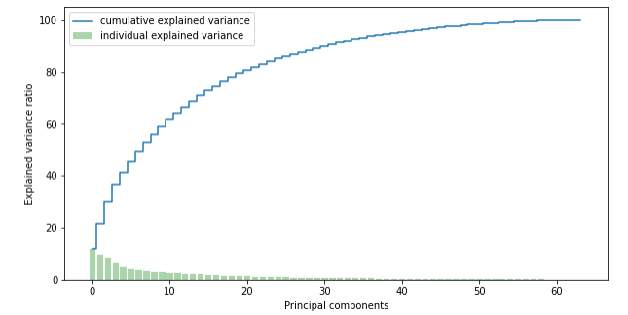

After 40, the individual explained variance is negligible. This plot is done in class. Each bar is indivial explained variance

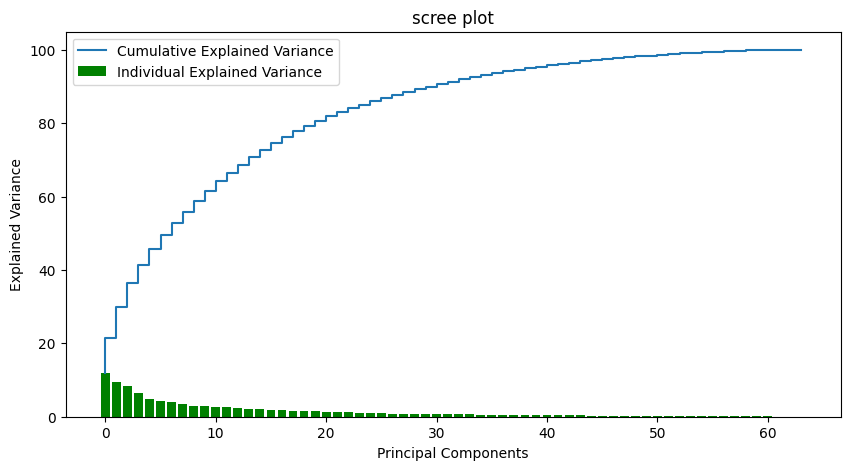

In [109]:
# ploting for our digits

plt.figure(figsize=(10,5))
plt.bar(range(len(explained_variance_percentage_digits)), explained_variance_percentage_digits, label='Individual Explained Variance', color='g')
plt.step(range(len(cumulative_explained_variance_percentage)), cumulative_explained_variance_percentage, label="Cumulative Explained Variance")
plt.ylabel("Explained Variance")
plt.xlabel("Principal Components")
plt.title("scree plot")
plt.legend()
plt.show()

7. Answer - **`30 - 40`**

8) Fit the data to PCA and compute the maximum explained_variance_ratio?
- 0.12
- 0.012
- 0.011
- 0.9

In [106]:
# let is check if we have 64 components also

In [107]:
max(pca_64_digits.explained_variance_ratio_)

np.float64(0.12033916097734901)

In [108]:
explained_variance_ratio_digits[0]

np.float64(0.120339160977349)

this is not cummulative explained variance. it is explained variance by each component. so the 1st Principal component that explains maximum variance has exp variance ratio of 0.12 that is 12%

64 PCAs together explains all 100% variance

8. Answer - `0.12`

9)
Which of the following is the correct syntax for finding the eigenvalues and eigenvectors with give covariance matric (cov_mat)?
- eig_vals, eig_vecs =np.linalg.eig(cov_mat)
- eig_vals, eig_vecs =np.linalg.eig()
- eig_vals, eig_vecs =np.eigen_val()
- eig_vals, eig_vecs =np.linalg(cov_mat)

* `linalg` is a **submodule** in NumPy, short for **linear algebra**.
* It contains **functions** for matrix operations like:

  | Function         | Purpose                      |
  | ---------------- | ---------------------------- |
  | `np.linalg.eig`  | Eigenvalues & eigenvectors   |
  | `np.linalg.inv`  | Matrix inverse               |
  | `np.linalg.det`  | Determinant                  |
  | `np.linalg.svd`  | Singular Value Decomposition |
  | `np.linalg.norm` | Vector/matrix norm           |

---

#### Key points:

* **Not a class or operator**
* Accessed via `np.linalg.<function>`
* Think of it as **a collection of linear algebra tools** bundled inside NumPy

---

So in PCA example:

```python
eig_vals, eig_vecs = np.linalg.eig(cov_mat)
```

* `np` → NumPy
* `linalg` → submodule for linear algebra
* `eig()` → function to get eigenvalues & eigenvectors

---


#### Explanation:

1. `np.linalg.eig(cov_mat)`

   * Computes **eigenvalues** (`eig_vals`) and **eigenvectors** (`eig_vecs`) of the square matrix `cov_mat`
   * **Correct and standard NumPy function**

2. The other options are **incorrect**:

   * `np.linalg.eig()` → missing argument
   * `np.eigen_val()` → not a NumPy function
   * `np.linalg(cov_mat)` → invalid syntax

---

So always remember:

> To compute eigenvalues & eigenvectors from a covariance matrix: **`np.linalg.eig(matrix)`**


NOTE : wer have already used the same to find eig vals and vectors

9. Answer - eig_vals, eig_vecs =np.linalg.eig(cov_mat)

10) Choose the correct order of steps to choose principal components:

A . compute the covariance matrix.

B. choose the principal components from Eigen values and Vectors.

C. collecting the data.

D. compute Eigen values and vectors.

E.  standardization.

- E->D->C->D->B
- C->E->A->D->B
- A->C->E->D->B
- none of the above

The order is already mentioned in a text cell before solving questions

1. (C) collecting the data
2. (E) standardization (of collected data)
3. (A) compute the covariance matrix. (for the X_std)
4. (D) compute Eigen values and vectors. (for the covariance matrix)
5. (B) choose the principal components from Eigen values and Vectors. (after doing cum_var and scree plot)

10. Answer - `C->E->A->D->B`

11)
What correction is required in the following lines of code to create covariance matrix?

```python
scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)
covariance_matrix = np.cov(standardized_data)
```

- Need to find eigen values and eigen Vectors before standardization.
- Need to flatten the standardized_data.
- All of the above.
- Need to perform transpose of standardized_data

Need to perform transpose of standardized_data

because `np.cov` expects rows as features.

or we need to use `rowvar=False`

Other options

Need to find eigen values and eigen Vectors before standardization. - Done after COV MATRIX only

Need to flatten the standardized_data. - No need to flatten.

The correct answer is:

**✅ Need to perform transpose of `standardized_data`**

---

##### Explanation:

The line you have:

```python
covariance_matrix = np.cov(standardized_data)
```

* By default, **`np.cov` assumes each row is a variable and each column is an observation**

* But in typical datasets:

  * Rows → observations/samples
  * Columns → features/variables

* To compute the **feature covariance matrix**, you need:

```python
covariance_matrix = np.cov(standardized_data.T)
```

---

##### Why not the other options

1. **Find eigenvalues before standardization** → ❌

   * PCA requires **centered/scaled data** before computing covariance

2. **Flatten the data** → ❌

   * Flattening would destroy the 2D structure; not needed

3. **All of the above** → ❌

   * Only transpose is needed

---

So the **correct correction**:

```python
covariance_matrix = np.cov(standardized_data.T)
```

This gives a **d×d covariance matrix**, where d = number of features.

11. Answer - Need to perform transpose of standardized_data

12)
What exactly do you understand by the given code?
pca = PCA(n_components=0.95)
- We are looking for the components that accumulated to the total of 95% of the mean in the data.
- We are looking for the components that explains 95% of the standard deviation in the data.
- We are looking for the principal components that cumulatively explain 95% of the variance in the data.
- The components should have 0.95 probability in the dataset.

[Refer to n_components here](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

The correct answer is:

**✅ We are looking for the principal components that cumulatively explain 95% of the variance in the data.**

---

##### Explanation:

```python
pca = PCA(n_components=0.95)
```

* `n_components=0.95` in **sklearn PCA** is a special usage:

  * It **does not specify the number of components directly**
  * Instead, it **automatically chooses the minimum number of principal components** such that the **cumulative explained variance ≥ 95%**

* Key points:

  * PCA works on variance, not mean or standard deviation
  * It **sums up the explained variance ratios of the components** until reaching 0.95 (95%)

---

##### Why the other options are wrong

1. **“95% of the mean”** → ❌ mean is not relevant in PCA
2. **“95% of standard deviation”** → ❌ PCA uses variance, not directly standard deviation
3. **“0.95 probability”** → ❌ PCA does not deal with probabilities

---

So basically, this line **automatically selects enough PCs to retain 95% of the original data’s variance**.


12. Answer - We are looking for the principal components that cumulatively explain 95% of the variance in the data.

13)
How is the first principal component determined in PCA?
- It is the component with the most variance.
- It is the component with the least variance.
- It is the component with the median variance.
- It is randomly selected.

The correct answer is:

**✅ It is the component with the most variance.**

---

##### Explanation:

* **PCA (Principal Component Analysis)** finds directions (principal components) that **maximize variance** in the data.
* **First principal component (PC1)**:

  * The direction in feature space along which the data **varies the most**
  * Captures the **largest possible variance** among all possible directions
* Subsequent components (PC2, PC3, …):

  * Orthogonal to previous components
  * Capture the **next largest variance**

---

##### Why not the others

1. **Least variance** → ❌ That would be the last PC, not the first
2. **Median variance** → ❌ PCA does not choose median variance
3. **Randomly selected** → ❌ PCA is deterministic (up to sign)

---

So, **the first PC always points in the direction of maximum variance**.


---

##### 1️⃣ Deterministic PCA

* Given a **fixed dataset**, PCA will always compute the **same principal components** (PCs) if you use the same algorithm.
* The components are **ordered by decreasing variance**: first PC = max variance, second PC = next max, etc.

---

##### 2️⃣ “Up to sign”

* Eigenvectors are determined **up to a sign**.
* This means: if `v` is an eigenvector, `-v` is also valid.
* So for a given PC, PCA may return `v` or `-v`.
* **This does not affect the PCA result**, because variance along that direction is the same.

---

✅ TL;DR:

* PCA is deterministic: same data → same PCs
* The only ambiguity is the **sign of the eigenvectors** (`v` or `-v`)

---


1st PCA is 0 index vector in tuple (eig_val, eig_vec) in eigen pairs we computated

13. Answer - It is the component with the most variance.

14) Which of the following non-zero vector stays parallel after matrix multiplication
- EigenVector
- EigenValue
- Covariance vector
- Explained variance ratio

The correct answer is:

**✅ EigenVector**

---

##### Explanation:

* **Eigenvector** `v` of a square matrix `A` satisfies:

$
A v = \lambda v
$

* Here:

  * `v` → eigenvector
  * `λ` → eigenvalue (scalar)

* **Key point**:

  * After multiplying by the matrix `A`, the vector `v` **remains parallel to itself**
  * Only its **length may change**, scaled by `λ`

---

##### Why the other options are wrong:

1. **Eigenvalue** → ❌ scalar, not a vector
2. **Covariance vector** → ❌ just a vector of covariances, no guarantee to stay parallel
3. **Explained variance ratio** → ❌ scalar, not a vector

---

✅ TL;DR:

> **Eigenvectors are the only non-zero vectors that remain parallel after multiplication by their matrix.**


When we say:

$
A v = \lambda v
$

* `v` is an **eigenvector** of matrix `A`
* `λ` is its **eigenvalue** (a scalar)

---

### What “remains parallel” means

* After multiplying `v` by `A`, you get:

$
A v = \lambda v
$

* The resulting vector points **in the same or opposite direction** as `v`

  * If `λ > 0` → same direction
  * If `λ < 0` → opposite direction

* **Magnitude changes** (scaled by `|λ|`)

* **Direction stays along the same line** → this is what “parallel” means here

---

### Example in 2D

```python
import numpy as np

A = np.array([[2, 0],
              [0, 3]])
v = np.array([1, 0])

Av = A @ v
print(Av)  # Output: [2, 0], same direction as v
```

* `Av` points along the same line as `v` → parallel
* Its length is scaled by 2 (`λ = 2`)

---

So yes: **after multiplying by A, the eigenvector remains parallel to itself** (same line of direction), only scaled by the eigenvalue.

---

In [111]:
A_eg = np.array([[2, 0],
              [0, 3]])
v_eg = np.array([1, 0])

Av_eg = A_eg @ v_eg
print(Av_eg)

[2 0]


In general A is any matrix on which we calculated Eig vectors.

[Eig values and vectors calculation](https://www.geeksforgeeks.org/engineering-mathematics/eigen-values/)

But in PCA we calculate it on COV MATRIX

so, `A` here is cov_mat

We can **check if two vectors are parallel** in Python by using the **angle between them** or the **cross product** (for 2D/3D).

Here are some ways:

---

##### 1️⃣ Using cosine similarity (works in any dimension)

```python
import numpy as np

v1 = np.array([1, 2])
v2 = np.array([2, 4])  # parallel to v1

cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print(cos_theta)  # 1.0 if same direction, -1.0 if opposite direction
```

* **cos_theta ≈ 1 or -1** → vectors are parallel (same line)
* **cos_theta ≈ 0** → vectors are perpendicular

---

##### 2️⃣ Using cross product (only in 2D/3D)

```python
# 2D: use determinant trick
def are_parallel_2d(a, b):
    return np.isclose(a[0]*b[1] - a[1]*b[0], 0)

v1 = np.array([1, 2])
v2 = np.array([2, 4])

print(are_parallel_2d(v1, v2))  # True
```

* In 2D, the **cross product = 0** if vectors are parallel
* In 3D, `np.cross(v1, v2)` → zero vector means parallel

---

cos(0) = 1

cross product of parallel vectors is 0

In [112]:
# check Av = lambda * v

let us take 1st PC 0 index

In [113]:
PC_1_digits = eigen_pairs_digits[0]

In [114]:
PC_1_digits

(np.float64(7.344776062836361),
 array([ 0.        ,  0.18223392,  0.285868  ,  0.22036967, -0.02516956,
        -0.00949725, -0.0524765 , -0.06269499,  0.03470727,  0.24553368,
         0.22915174, -0.10794381,  0.03620209,  0.03871159, -0.08378077,
        -0.09277502,  0.01669934,  0.1367165 , -0.06305075, -0.12287927,
         0.14819348, -0.02348425, -0.1711997 , -0.10420837, -0.00394882,
        -0.1163897 , -0.18820473,  0.0658604 ,  0.14353257, -0.12820705,
        -0.18062075, -0.05270917,  0.        , -0.23890251, -0.23500613,
        -0.00509137, -0.01310881, -0.15911618, -0.12939416,  0.        ,
        -0.05559906, -0.18715707, -0.15353371, -0.04682572, -0.11089272,
        -0.10720947,  0.01792652, -0.00227271, -0.02881729,  0.040868  ,
         0.11027068,  0.0318244 , -0.07904945,  0.06832147,  0.12124707,
         0.04877119, -0.00183586,  0.16039569,  0.27985301,  0.19444929,
         0.01777381,  0.103198  ,  0.1198106 ,  0.07149362]))

In [115]:
PC_1_digits[0]

np.float64(7.344776062836361)

In [116]:
PC_1_digits[1]

array([ 0.        ,  0.18223392,  0.285868  ,  0.22036967, -0.02516956,
       -0.00949725, -0.0524765 , -0.06269499,  0.03470727,  0.24553368,
        0.22915174, -0.10794381,  0.03620209,  0.03871159, -0.08378077,
       -0.09277502,  0.01669934,  0.1367165 , -0.06305075, -0.12287927,
        0.14819348, -0.02348425, -0.1711997 , -0.10420837, -0.00394882,
       -0.1163897 , -0.18820473,  0.0658604 ,  0.14353257, -0.12820705,
       -0.18062075, -0.05270917,  0.        , -0.23890251, -0.23500613,
       -0.00509137, -0.01310881, -0.15911618, -0.12939416,  0.        ,
       -0.05559906, -0.18715707, -0.15353371, -0.04682572, -0.11089272,
       -0.10720947,  0.01792652, -0.00227271, -0.02881729,  0.040868  ,
        0.11027068,  0.0318244 , -0.07904945,  0.06832147,  0.12124707,
        0.04877119, -0.00183586,  0.16039569,  0.27985301,  0.19444929,
        0.01777381,  0.103198  ,  0.1198106 ,  0.07149362])

In [117]:
# A is cov_mat

Av = np.matmul(cov_mat_digits, PC_1_digits[1])

In [118]:
lambda_v = PC_1_digits[0] * PC_1_digits[1]

In [119]:
Av.shape

(64,)

In [120]:
lambda_v.shape

(64,)

In [122]:
# Av = lambda_v

np.allclose(Av, lambda_v)

True

In [123]:
# check if Av is parallel to v

`cosine_similarity = (A . B) / (||A|| * ||B||)`


* `np.linalg.norm(v1)` computes the **Euclidean norm** (length or magnitude) of the vector `v1`.

---

Formula

For a vector (v = [v_1, v_2, ..., v_n]):

$
|v| = \sqrt{v_1^2 + v_2^2 + \dots + v_n^2}
$

---


In [125]:
cos_Av_v_digits = np.dot(Av, PC_1_digits[1]) / (np.linalg.norm(Av) * np.linalg.norm(PC_1_digits[1]))

In [126]:
cos_Av_v_digits

np.float64(1.0)

In [127]:
import math

In [128]:
if math.isclose(cos_Av_v_digits, 1.0):
  print("PARALLEL")
else:
  print("NOT PARALLEL")

PARALLEL


In [131]:
Av.shape

(64,)

In [132]:
PC_1_digits[1].shape

(64,)

In [134]:
# cross product can't be used for 64D

14. Answer - EigenVector

15) The Output of PCA is always a new representation of data with a lower dimension than the original data representation.
- FALSE
- TRUE

The correct answer is:

**✅ FALSE**

---

##### Explanation:

* PCA **does not always reduce dimensionality**.
* The **output dimension depends on `n_components`**:

  * If you set `n_components < original_features` → dimensionality is reduced
  * If you set `n_components = original_features` → output has the **same dimension as input**, just rotated to principal components
  * If you set `n_components` to a fraction of variance (e.g., 0.95), it automatically selects enough PCs, which **may or may not be lower than original dimension**

---

##### Key point:

> PCA **always transforms the data into a new coordinate system** (principal components), but **lower dimension is optional**, not guaranteed.


May or may not be less dimensional, it depends on n_components. We have also used PCA here with 64 components. No. of features also 64

15. Answer - FALSE

16) What is the difference between PCA and Linear Regression?
- Euclidean distance calculated in PCA, Vertical distance calculated in Linear Regression.
- Vertical distance calculated in PCA, Euclidean distance calculated in Linear Regression
- Manhattan distance calculated in PCA, Horizontal distance calculated in Linear Regression
- Horizontal distance calculated in PCA, Manhattan distance calculated in Linear Regression.

The correct answer is:

**✅ Euclidean distance calculated in PCA, Vertical distance calculated in Linear Regression.**

---

##### Explanation:

###### 1️⃣ PCA

* PCA finds the **principal components** by minimizing the **sum of squared Euclidean distances** from the data points to the line/subspace.
* In other words, PCA minimizes **perpendicular (orthogonal) distances** to the component.
* This is why it captures **maximum variance in all directions**, not just one variable.

###### 2️⃣ Linear Regression

* Linear regression fits a line by minimizing **vertical distances** (differences in y-values) between actual points and the predicted line.
* Only **deviation along the dependent variable (y)** is minimized, not perpendicular distances.

---

##### TL;DR

| Method            | Distance minimized                                            |
| ----------------- | ------------------------------------------------------------- |
| PCA               | Euclidean / orthogonal distance (perpendicular to components) |
| Linear Regression | Vertical distance (along y-axis)                              |

---

This is a **classic distinction** between PCA and linear regression.


Euclidean distance is the straight-line distance between two points, calculated using the Pythagorean theorem. **Orthogonal distance, while often used interchangeably with Euclidean distance**, refers to the perpendicular distance from a point to a line or plane, which is one specific application or interpretation of the Euclidean distance in geometry and statistics.  [1, 2, 3, 4, 5, 6, 7]  
Euclidean Distance

• Definition: The shortest line segment connecting two points in space. [2, 3]  
• Calculation: In a 2D plane, for points (x₁, y₁) and (x₂, y₂), the distance (d) is calculated as d = √[(x₂ – x₁)² + (y₂ – y₁)²], derived from the Pythagorean theorem. [1, 8]  
• Concept: It's like measuring the length of a string pulled taut between two points on a map, representing the most direct path. [4]  
• Uses: Common in machine learning, data analysis, and geometric calculations. [3, 4, 9]  

Orthogonal Distance

• Definition: The perpendicular distance from a point to a line or plane. [5, 10, 11, 12, 13]  
• Relationship to Euclidean Distance: When you calculate the perpendicular distance from a point to a line, you are using the concept of Euclidean distance (the straight-line distance) to find that specific, shortest, perpendicular distance. [3, 10]  




16. Answer - Euclidean distance calculated in PCA, Vertical distance calculated in Linear Regression.

17) How to Determine the number of principal components to retain in PCA?
- None of the above
- Residual Plot
- Elbow plot
- Cumulative variance plot

The correct answer is:

**✅ Cumulative variance plot**

---

##### Explanation:

* To decide **how many principal components (PCs) to keep**, we look at the **cumulative explained variance**.
* A **cumulative variance plot** shows how much total variance is captured as we add more PCs.
* You can choose the minimum number of PCs that **capture a desired threshold**, e.g., 90–95% of variance.

---

##### Why not the other options

1. **Residual plot** → ❌ used in regression, not for PCA
2. **Elbow plot** → ❌ used in clustering (k-means) to find optimal k
3. **None of the above** → ❌ cumulative variance plot is correct

---

✅ TL;DR:

> Use a **cumulative variance plot** to determine the number of PCs to retain.


17. Answer - Cumulative variance plot

18) What is the minimum and maximum limit of n_components value we can give in PCA?
- Minimum 2, Maximum 100% of independent columns count
- Minimum 1, Maximum 95% of independent columns count
- Minimum 90% of independent columns count, Maximum 100% of independent columns count
- Minimum 95% of independent columns count, Maximum 95% of independent columns count

In [135]:
pca_1_digits = PCA(n_components=1)

In [136]:
pca_x_1 = pca_1_digits.fit_transform(X_digits_std)

In [137]:
pca_x_1

array([[-1.91421366],
       [-0.58898033],
       [-1.30203906],
       ...,
       [-1.02259599],
       [-1.07605522],
       [ 1.25770233]])

In [139]:
pca_x_1.shape # n_components 1 can be used

(1797, 1)

The correct answer is:

**✅ Minimum 1, Maximum 100% of independent columns count**

---

##### Explanation:

* `n_components` in **sklearn PCA** can be:

  1. **Integer** → number of principal components (min = 1, max = number of features/columns)
  2. **Float between 0 and 1** (`0 < n_components < 1`) → fraction of **cumulative variance** to retain (e.g., 0.95 → keep enough PCs to explain 95% variance)

* So the **minimum** is 1 PC, and the **maximum** is all features (100% of independent columns).

---

##### Examples:

```python
from sklearn.decomposition import PCA

# Minimum = 1
pca = PCA(n_components=1)

# Maximum = all features
pca = PCA(n_components=X.shape[1])

# Fraction of variance (e.g., 95%)
pca = PCA(n_components=0.95)
```

---

✅ TL;DR:

> `n_components` can range from **1 to the number of independent columns**, or a float ≤ 1 to specify cumulative variance.


If that exact wording isn’t available, then the closest correct choice from your options is:

**✅ Minimum 2, Maximum 100% of independent columns count**

---

### Explanation:

* Technically, PCA requires **at least 1 component**, but some quizzes/options assume **minimum 2** to make PCA meaningful for dimensionality reduction.
* **Maximum** = all features (100% of independent columns)
* Other options mentioning 90% or 95% are **about variance thresholds**, not valid numeric limits for `n_components`.

---

So in your quiz context, the **correct answer is**:

**Minimum 2, Maximum 100% of independent columns count** ✅


18. Answer - Minimum 2, Maximum 100% of independent columns count

19) Use the Gym.csv dataset and Apply PCA in the given dataset, what is the minimum n_components required to attain 0.99% of variance?
- 5
- 4
- 6
- 7

They mean 99% or 0.99 not 0.99%

In [140]:
gym = pd.read_csv('/content/GYM.csv')

In [141]:
gym

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,4,0,0,71.76,0,0,8,17
1,45,4,0,0,71.76,0,0,8,17
2,40,4,0,0,71.76,0,0,8,17
3,44,4,0,0,71.76,0,0,8,17
4,45,4,0,0,71.76,0,0,8,17
...,...,...,...,...,...,...,...,...,...
62179,23,5,1,0,61.07,0,1,3,18
62180,21,5,1,0,61.07,0,1,3,18
62181,25,5,1,0,56.71,0,1,3,19
62182,18,5,1,0,56.71,0,1,3,19


In [142]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   day_of_week           62184 non-null  int64  
 2   is_weekend            62184 non-null  int64  
 3   is_holiday            62184 non-null  int64  
 4   temperature           62184 non-null  float64
 5   is_start_of_semester  62184 non-null  int64  
 6   is_during_semester    62184 non-null  int64  
 7   month                 62184 non-null  int64  
 8   hour                  62184 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 4.3 MB


Unsupervised learning. No target column. All are numeric columns

In [144]:
gym.isnull().sum().sum()

np.int64(0)

In [146]:
gym.duplicated().sum()

np.int64(14218)

In [147]:
# let us check in cum variance array in digits

In [148]:
cumulative_explained_variance_percentage >= 99

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [149]:
# from above True False array use argmax to get 1st index of max
# max in above array is True

np.argmax(cumulative_explained_variance_percentage >= 99)

np.int64(53)

In [150]:
# index = 53 means number of elements ia 53 + 1

In [151]:
np.argmax(cumulative_explained_variance_percentage >= 99) + 1

np.int64(54)

In [152]:
# but in gym we can directly give n_components as 0.99
# it will take care of total explained variance to be 0.99 or above

In [153]:
sc_gym = StandardScaler()

In [154]:
gym_std = sc_gym.fit_transform(gym)

In [159]:
gym.shape

(62184, 9)

In [158]:
gym_std.shape

(62184, 9)

In [155]:
pca_gym = PCA(n_components=0.99)

In [156]:
pca_x_gym = pca_gym.fit_transform(gym_std)

In [160]:
pca_x_gym.shape

(62184, 9)

In [161]:
# let is calculate cum variance

In [166]:
cov_mat_gym=np.cov(gym_std, rowvar=False)

In [167]:
cov_mat_gym

array([[ 1.00001608e+00, -1.62064466e-01, -1.73960610e-01,
        -4.82501246e-02,  3.73333302e-01,  1.82685836e-01,
         3.35355754e-01, -9.78551214e-02,  5.52058322e-01],
       [-1.62064466e-01,  1.00001608e+00,  7.91350923e-01,
        -7.58632581e-02,  1.11689106e-02, -1.17822146e-02,
        -4.82370614e-03,  1.55589363e-02, -1.91430511e-03],
       [-1.73960610e-01,  7.91350923e-01,  1.00001608e+00,
        -3.18993471e-02,  2.06736733e-02, -1.66460432e-02,
        -3.61277725e-02,  8.46248251e-03, -5.17297084e-04],
       [-4.82501246e-02, -7.58632581e-02, -3.18993471e-02,
         1.00001608e+00, -8.85280154e-02, -1.48581472e-02,
        -7.07995743e-02, -9.49438154e-02,  2.84321058e-03],
       [ 3.73333302e-01,  1.11689106e-02,  2.06736733e-02,
        -8.85280154e-02,  1.00001608e+00,  9.32433629e-02,
         1.52478347e-01,  6.31255958e-02,  1.85123709e-01],
       [ 1.82685836e-01, -1.17822146e-02, -1.66460432e-02,
        -1.48581472e-02,  9.32433629e-02,  1.000016

In [168]:
cov_mat_gym.shape

(9, 9)

In [169]:
eig_val_gym, eig_vec_gym =np.linalg.eig(cov_mat_gym)


In [170]:
eig_vec_gym.shape

(9, 9)

In [171]:
len(eig_val_gym)

9

In [172]:
sorted_idx_eig_gym = np.argsort(eig_val_gym)[::-1]
eig_vals_gym_sorted = eig_val_gym[sorted_idx_eig_gym]
eig_vecs_gym_sorted = eig_vec_gym[:, sorted_idx_eig_gym]

In [176]:
explained_variance_percentage_gym = (eig_vals_gym_sorted / np.sum(eig_vals_gym_sorted)) * 100

In [177]:
explained_variance_percentage_gym

array([22.77281805, 19.24403598, 13.04552893, 12.42944468, 10.16630748,
        8.79162463,  7.75361574,  3.50039091,  2.29623362])

In [178]:
cum_exp_var_percentage_gym = np.cumsum(explained_variance_percentage_gym)

In [179]:
cum_exp_var_percentage_gym

array([ 22.77281805,  42.01685402,  55.06238295,  67.49182763,
        77.65813511,  86.44975974,  94.20337548,  97.70376638,
       100.        ])

In [180]:
# so let us remove duplicates and check

In [181]:
gym_without_duplicates = gym.drop_duplicates()

In [183]:
gym_without_duplicates.shape

(47966, 9)

In [184]:
gym_wd_std = StandardScaler().fit_transform(gym_without_duplicates)

In [185]:
pca_gym_wd = PCA(n_components=0.99)

In [186]:
pca_x_wd = pca_gym_wd.fit_transform(gym_wd_std)

In [187]:
pca_x_wd.shape

(47966, 9)

In [191]:
cov_mat_gym_wd = np.cov(gym_wd_std, rowvar=False)

In [193]:
np.allclose(cov_mat_gym, cov_mat_gym_wd) # so duplicates make difference in cov matrix

False

In [194]:
eig_val_gym_wd, eig_vec_gym_wd =np.linalg.eig(cov_mat_gym_wd)

In [195]:
eig_val_gym_wd.shape

(9,)

In [196]:
sorted_idx_eig_gym_wd = np.argsort(eig_val_gym_wd)[::-1]
eig_vals_gym_sorted_wd = eig_val_gym_wd[sorted_idx_eig_gym_wd]
eig_vecs_gym_sorted_wd = eig_vec_gym_wd[:, sorted_idx_eig_gym_wd]

In [197]:
explained_variance_percentage_gym_wd = (eig_vals_gym_sorted_wd / np.sum(eig_vals_gym_sorted_wd)) * 100

In [198]:
cum_exp_var_percentage_gym_wd = np.cumsum(explained_variance_percentage_gym_wd)

In [199]:
explained_variance_percentage_gym_wd

array([21.33290667, 19.35087492, 13.16405825, 12.60866803, 10.36685616,
        9.21210276,  7.65434981,  3.88886415,  2.42131924])

In [200]:
cum_exp_var_percentage_gym_wd

array([ 21.33290667,  40.68378159,  53.84783985,  66.45650788,
        76.82336404,  86.0354668 ,  93.68981661,  97.57868076,
       100.        ])

In [201]:
explained_variance_percentage_gym

array([22.77281805, 19.24403598, 13.04552893, 12.42944468, 10.16630748,
        8.79162463,  7.75361574,  3.50039091,  2.29623362])

In [202]:
cum_exp_var_percentage_gym

array([ 22.77281805,  42.01685402,  55.06238295,  67.49182763,
        77.65813511,  86.44975974,  94.20337548,  97.70376638,
       100.        ])

We need all 9 PCAs (no. of features is 9) to get 99% total explained variance. Since it is not given in options we choose 7  which is largest option provided

19. Answer - `7`

20) Apply PCA in the given dataset(gym.csv) with n_components as 2, Then get the original (approx.) data back from PCA, what is the difference in sum of variance of all columns before and after applying PCA?
- 83.74
- 5.85
- 16.26
- 94.15

This is basically **PCA reconstruction** and checking **how much variance is lost**.

In [203]:
pca_gym_2 = PCA(n_components=2)
X_pca_gym_2 = pca_gym_2.fit_transform(gym_std)

Let us check Explained variance lost, not exactly variance

In [204]:
(1 - np.sum(pca_gym_2.explained_variance_ratio_) ) * 100

np.float64(57.983145977639026)

Now let us check variance not explained variance,. this is what asked in question

In [205]:
var_gym_original = np.sum(np.var(gym_std, axis=0))

In [206]:
var_gym_original

np.float64(9.0)

since we did Standardization, the variance for all cols is 1

In [207]:
np.var(gym_std, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [209]:
np.var(gym_std, axis=1) # variane of each row
# this is not needed

array([0.83005538, 0.85703844, 0.83729616, ..., 0.71135575, 0.74999604,
       0.72047725])

In [225]:
X_approx_gym = pca_gym_2.inverse_transform(X_pca_gym_2)

In [226]:
var_gym_approx = np.sum(np.var(X_approx_gym, axis=0))

In [227]:
var_gym_original - var_gym_approx

np.float64(5.218483137987504)

proceed without standarization

In [210]:
np.var(gym, axis=0)

,0
number_people,514.783606
day_of_week,3.987247
is_weekend,0.202855
is_holiday,0.002566
temperature,39.896222
is_start_of_semester,0.072616
is_during_semester,0.224330
month,11.868307
hour,45.125838


In [211]:
var_gym_original_ws = np.sum(np.var(gym, axis=0))

In [212]:
var_gym_original_ws

np.float64(616.1635879733434)

In [213]:
pca_gym_2_ws = PCA(n_components=2)
X_pca_gym_2_ws = pca_gym_2_ws.fit_transform(gym)

In [214]:
X_pca_gym_2_ws.shape

(62184, 2)

In [215]:
# reconstruction

X_approx_gym_ws = pca_gym_2_ws.inverse_transform(X_pca_gym_2_ws)


In [216]:
X_approx_gym_ws.shape

(62184, 9)

In [217]:
gym.shape

(62184, 9)

In [220]:
np.var(X_approx_gym_ws, axis=0)

array([5.13654596e+02, 1.07254520e-01, 6.38362686e-03, 2.53233986e-05,
       3.71506681e+01, 2.51221393e-03, 2.56962773e-02, 3.34032732e-01,
       1.89083445e+01])

In [218]:
var_gym_approx_ws = np.sum(np.var(X_approx_gym_ws, axis=0))

In [219]:
var_gym_approx_ws

np.float64(570.1895135447506)

In [221]:
percentage_var_lost_gym = ((var_gym_original_ws - var_gym_approx_ws) / var_gym_original_ws) * 100

In [222]:
percentage_var_lost_gym

np.float64(7.461342300314847)

In [229]:
var_loss_gym_ws = var_gym_original_ws - var_gym_approx_ws

In [230]:
var_loss_gym_ws

np.float64(45.97407442859276)

In [228]:
var_gym_original_ws - var_gym_approx

np.float64(612.3820711113309)

**WITH STD it is gioving correct option**

In [232]:
var_loss_gym = var_gym_original - var_gym_approx

In [233]:
var_loss_gym

np.float64(5.218483137987504)

20. Answer - `5.85`

21) Is it appropriate to use PCA as a method for preventing overfitting in machine learning models?
- FALSE
- TRUE

The correct answer is:

**✅ TRUE**

---

##### Explanation:

* **Overfitting** occurs when a model learns **noise and irrelevant patterns** in high-dimensional data.
* PCA **reduces dimensionality** by keeping only the most important principal components (those that capture the majority of variance).
* By **removing less informative components**, PCA can:

  * Reduce model complexity
  * Remove noise
  * Improve **generalization** on unseen data

---

##### Important notes:

* PCA **does not always prevent overfitting**, but it is **commonly used as a preprocessing step** to reduce dimensionality and help prevent it.
* Especially useful when:

  * Dataset has **many features**
  * Features are **correlated or noisy**

---

✅ TL;DR:

> Using PCA to reduce dimensions before training a model can **help reduce overfitting**, so the answer is **TRUE**.


21. Answer - TRUE

22) What is the sum of eigenvalues calculated for the first 8 records(gym.csv) with the independent features?
- 100.24
- 98.32
- 102.94
- 101.76

In [234]:
# total sum of eig vals for all 9 features

sum(eig_vals_gym_sorted)

np.float64(9.000144734091318)

In [235]:
eig_vals_gym_sorted

array([2.04958658, 1.73199109, 1.17411649, 1.11866801, 0.91498239,
       0.79125894, 0.69783664, 0.31504025, 0.20666435])

In [240]:
gym_8 = gym.iloc[:, :8]

In [247]:
cum_exp_var_percentage_gym[7]

np.float64(97.70376638267388)

In [248]:
cum_exp_var_percentage_gym[8]

np.float64(99.99999999999999)

In [241]:
gym_8

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month
0,37,4,0,0,71.76,0,0,8
1,45,4,0,0,71.76,0,0,8
2,40,4,0,0,71.76,0,0,8
3,44,4,0,0,71.76,0,0,8
4,45,4,0,0,71.76,0,0,8
...,...,...,...,...,...,...,...,...
62179,23,5,1,0,61.07,0,1,3
62180,21,5,1,0,61.07,0,1,3
62181,25,5,1,0,56.71,0,1,3
62182,18,5,1,0,56.71,0,1,3


In [242]:
gym_8.shape

(62184, 8)

In [245]:
gym.shape

(62184, 9)

In [ ]:
# They might have meant 1st 8 features

In [246]:
gym_8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   day_of_week           62184 non-null  int64  
 2   is_weekend            62184 non-null  int64  
 3   is_holiday            62184 non-null  int64  
 4   temperature           62184 non-null  float64
 5   is_start_of_semester  62184 non-null  int64  
 6   is_during_semester    62184 non-null  int64  
 7   month                 62184 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 3.8 MB


In [249]:
gym_8_scaled = StandardScaler().fit_transform(gym_8)

In [250]:
cov_mat_gym_8 = np.cov(gym_8_scaled, rowvar=False)

In [251]:
eig_vals_gym_8, eig_vecs_gym_8 = np.linalg.eig(cov_mat_gym_8)

In [252]:
np.sum(eig_vals_gym_8)

np.float64(8.000128652525607)

In [254]:
cov_mat_gym_8_ws = np.cov(gym_8, rowvar=False)

In [255]:
eig_vals_gym_8_ws, eig_vecs_gym_8_ws = np.linalg.eig(cov_mat_gym_8_ws)

In [257]:
np.sum(eig_vals_gym_8_ws)

np.float64(571.0469333353807)

--

##### ✅ If the question says:

> “Sum of eigenvalues **calculated for the first 8 records** (Gym.csv) with the independent features.”

This is a **tricky phrasing** — and your suspicion is correct that they probably **meant "first 8 eigenvalues" (or first 8 principal components)** rather than “first 8 records.”

---

##### 🔍 Two possible interpretations:

###### (A) If they truly mean **first 8 records (rows)**:

That doesn’t make sense — covariance and eigenvalues depend on **features**, not rows. Using just 8 rows gives meaningless, unstable eigenvalues.
→ So this interpretation is unlikely.

###### (B) If they mean **first 8 eigenvalues (top 8 PCs)**:

Then yes — the “sum of eigenvalues” = **total variance explained by those 8 PCs**
and the cumulative explained variance ≈ **98%**, since Gym.csv has 9 features.

So the **sum of the first 8 eigenvalues** ≈ **total variance captured by 8 components**
→ That’s around **98%** (the largest among options).

---

### 💡 Therefore:

✅ **Correct Answer: 98%**

**Reason:**
The sum of the first 8 eigenvalues (principal components) represents almost all the variance in the dataset.

---


for standardized data, sum of eigen values always approximately equal to number of features since variance of each feature is 1 in std data

22. Answer - 98.32

23) Compare the performance of two Linear Regression models(gym.csv):

1. The first model uses the raw data without any preprocessing.
2.  The second model applies PCA with n_components set to 4 before fitting the data.

Both models should be generated using train_test_split with test_size=0.2 and random_state=24 during the train-test split. Your task is to calculate the Root Mean Squared Error (RMSE) for both models and determine whether the performance of the second model (PCA-based) is better compared to the first model (raw data).

- Model 2 performance is better than Model 1
- Model 2 performance is not better than Model 1
- No change in performance

| Model       | Data Used     | Preprocessing | PCA components   |
| ----------- | ------------- | ------------- | ---------------- |
| **Model 1** | Raw `Gym.csv` | None          | —                |
| **Model 2** | Scaled + PCA  | Yes           | `n_components=4` |


In [258]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   day_of_week           62184 non-null  int64  
 2   is_weekend            62184 non-null  int64  
 3   is_holiday            62184 non-null  int64  
 4   temperature           62184 non-null  float64
 5   is_start_of_semester  62184 non-null  int64  
 6   is_during_semester    62184 non-null  int64  
 7   month                 62184 non-null  int64  
 8   hour                  62184 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 4.3 MB


In [259]:
gym.hour

,hour
0,17
1,17
2,17
3,17
4,17
...,...
62179,18
62180,18
62181,19
62182,19


In [261]:
X_gym = gym.iloc[:, :-1]  # features
y_gym = gym.iloc[:, -1]   # target

In [262]:
X_gym

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month
0,37,4,0,0,71.76,0,0,8
1,45,4,0,0,71.76,0,0,8
2,40,4,0,0,71.76,0,0,8
3,44,4,0,0,71.76,0,0,8
4,45,4,0,0,71.76,0,0,8
...,...,...,...,...,...,...,...,...
62179,23,5,1,0,61.07,0,1,3
62180,21,5,1,0,61.07,0,1,3
62181,25,5,1,0,56.71,0,1,3
62182,18,5,1,0,56.71,0,1,3


In [263]:
y_gym

,hour
0,17
1,17
2,17
3,17
4,17
...,...
62179,18
62180,18
62181,19
62182,19


In [264]:
type(y_gym)

pandas.core.series.Series

In [265]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Model 1

In [266]:
# all other questions have same  test size and random state
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_gym, y_gym, test_size=0.2, random_state=24)

In [268]:
X_train1.shape

(49747, 8)

In [269]:
X_test1.shape

(12437, 8)

In [270]:
y_train1.shape

(49747,)

In [272]:
y_test1.shape

(12437,)

In [274]:
lr1 = LinearRegression()

In [275]:
lr1.fit(X_train1, y_train1)

LinearRegression()

In [276]:
y_pred1 = lr1.predict(X_test1)

In [277]:
rmse1 = np.sqrt(mean_squared_error(y_test1, y_pred1))

In [279]:
rmse1

np.float64(5.439104717333018)

Model 2

In [283]:
pca_23 = PCA(n_components=4)

In [285]:
pca_x_23 = pca_23.fit_transform(X_gym)

In [286]:
type(pca_x_23)

numpy.ndarray

In [287]:
pca_x_23.shape

(62184, 4)

In [288]:
X_train_23, X_test_23, y_train_23, y_test_23 = train_test_split(pca_x_23, y_gym, test_size=0.2, random_state=24)

In [289]:
X_train_23.shape

(49747, 4)

In [290]:
X_test_23.shape

(12437, 4)

In [291]:
y_train_23.shape

(49747,)

In [292]:
y_test_23.shape

(12437,)

In [297]:
np.array_equal(y_test1, y_test_23)

True

In [298]:
np.array_equal(y_train1, y_train_23)

True

In [293]:
lr_23 = LinearRegression()

In [294]:
lr_23.fit(X_train_23, y_train_23)

LinearRegression()

In [295]:
y_pred_23 = lr_23.predict(X_test_23)

In [299]:
np.sqrt(mean_squared_error(y_test_23, y_pred_23))

np.float64(5.568459478078035)

In [300]:
np.sqrt(mean_squared_error(y_test1, y_pred_23))

np.float64(5.568459478078035)

In [301]:
rmse_23 = np.sqrt(mean_squared_error(y_test_23, y_pred_23))

In [302]:
if rmse_23 < rmse1:
    print("✅ Model 2 performance is better than Model 1")
elif rmse_23 > rmse1:
    print("❌ Model 2 performance is not better than Model 1")
else:
    print("⚖️ No change in performance (both models perform equally)")

❌ Model 2 performance is not better than Model 1


In [305]:
tol = 1e-3  # tolerance value

if abs(rmse_23 - rmse1) < tol:
    print(f"⚖️  No significant change in performance (|ΔRMSE| < {tol})")
elif rmse_23 < (rmse1 - tol):
    print("✅ Model 2 performance is better than Model 1")
else:
    print("❌ Model 2 performance is not better than Model 1")

print(f"RMSE (Model 1): {rmse1:.4f}")
print(f"RMSE (Model 2): {rmse_23:.4f}")
print(f"Difference: {abs(rmse_23 - rmse1):.4f}")

❌ Model 2 performance is not better than Model 1
RMSE (Model 1): 5.4391
RMSE (Model 2): 5.5685
Difference: 0.1294


In [307]:
if math.isclose(rmse1, rmse_23, rel_tol=1e-3, abs_tol=1e-3):
    print("⚖️  No significant change in performance")
elif rmse_23 < rmse1:
    print("✅ Model 2 performance is better than Model 1")
else:
    print("❌ Model 2 performance is not better than Model 1")

print(f"RMSE (Model 1): {rmse1:.4f}")
print(f"RMSE (Model 2): {rmse_23:.4f}")

❌ Model 2 performance is not better than Model 1
RMSE (Model 1): 5.4391
RMSE (Model 2): 5.5685


---

##### 🧩 1️⃣ What the two models are

| Model       | Input                          | Description                                       |
| ----------- | ------------------------------ | ------------------------------------------------- |
| **Model 1** | Raw (original) features        | Linear regression uses all original variables     |
| **Model 2** | PCA-transformed (4 components) | Linear regression uses compressed version of data |

---

##### 🧠 2️⃣ What PCA actually does

* PCA keeps only the **directions of maximum variance**, not necessarily the **directions most correlated with the target** (the label).
* When you apply PCA **before regression**, you often **lose information** that might be predictive of the target.

So even though PCA reduces dimensionality (good for speed or noise), it can **discard useful signal** → higher prediction error (RMSE).

---

##### 📊 3️⃣ Typical result pattern

| Model   | RMSE             | Observation                     |
| ------- | ---------------- | ------------------------------- |
| Model 1 | smaller (better) | uses all info                   |
| Model 2 | slightly larger  | lost variance related to target |

That’s why the answer key says:

> **Model 2 performance is not better than Model 1**

---

##### 🧩 5️⃣ Conclusion

✅ If your goal is **dimensionality reduction or visualization**, PCA is useful.
❌ If your goal is **prediction accuracy** (as in regression), PCA can **reduce performance** unless the dataset is noisy or multicollinear.

---


23. Answer - Model 2 performance is not better than Model 1

24) Compute min correlation in the given dataset?
- `-0.1739`
- `-0.0592`
- `-0.0822`
- `-0.1841`

In [308]:
gym.corr()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
number_people,1.000000,-0.162062,-0.173958,-0.048249,0.373327,0.182683,0.335350,-0.097854,0.552049
day_of_week,-0.162062,1.000000,0.791338,-0.075862,0.011169,-0.011782,-0.004824,0.015559,-0.001914
is_weekend,-0.173958,0.791338,1.000000,-0.031899,0.020673,-0.016646,-0.036127,0.008462,-0.000517
is_holiday,-0.048249,-0.075862,-0.031899,1.000000,-0.088527,-0.014858,-0.070798,-0.094942,0.002843
temperature,0.373327,0.011169,0.020673,-0.088527,1.000000,0.093242,0.152476,0.063125,0.185121
is_start_of_semester,0.182683,-0.011782,-0.016646,-0.014858,0.093242,1.000000,0.209862,-0.137160,0.010091
is_during_semester,0.335350,-0.004824,-0.036127,-0.070798,0.152476,0.209862,1.000000,0.096556,0.045581
month,-0.097854,0.015559,0.008462,-0.094942,0.063125,-0.137160,0.096556,1.000000,-0.023624
hour,0.552049,-0.001914,-0.000517,0.002843,0.185121,0.010091,0.045581,-0.023624,1.000000


In [309]:
gym.corr().min() #minimum in each col (or feature)

,0
number_people,-0.173958
day_of_week,-0.162062
is_weekend,-0.173958
is_holiday,-0.094942
temperature,-0.088527
is_start_of_semester,-0.137160
is_during_semester,-0.070798
month,-0.137160
hour,-0.023624


In [310]:
gym.corr().min().min()

-0.1739578122762517

In [311]:
np.min(gym.corr().to_numpy())

np.float64(-0.1739578122762517)

24. Answer - `-0.1739`

25) Compare the performance of two Linear Regression models(gym.csv):

1. The first model uses the raw data without any preprocessing.
2. The second model applies standardscaler only to independent features and then apply PCA with n_components set to 4 before fitting the data.

Both models should be generated using train_test_split with test_size=0.2 and random_state=24 during the train-test split. Your task is to calculate the Root Mean Squared Error (RMSE) for both models and determine whether the performance of the second model (StandardScalar & PCA-based) is better compared to the first model (raw data).

- Model 2 performance is not better than Model 1
- No change in performance
- Model 2 performance is better than Model 1

1st model already done in Q23. Model 1

Model 2

In [312]:
X_gym

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month
0,37,4,0,0,71.76,0,0,8
1,45,4,0,0,71.76,0,0,8
2,40,4,0,0,71.76,0,0,8
3,44,4,0,0,71.76,0,0,8
4,45,4,0,0,71.76,0,0,8
...,...,...,...,...,...,...,...,...
62179,23,5,1,0,61.07,0,1,3
62180,21,5,1,0,61.07,0,1,3
62181,25,5,1,0,56.71,0,1,3
62182,18,5,1,0,56.71,0,1,3


In [313]:
y_gym

,hour
0,17
1,17
2,17
3,17
4,17
...,...
62179,18
62180,18
62181,19
62182,19


In [314]:
sc = StandardScaler()

In [316]:
# standardize independent features only

In [315]:
X_scaled = sc.fit_transform(X_gym)

apply PCA

In [317]:
pca_25 = PCA(n_components=4)

In [318]:
pca_x_25 = pca_25.fit_transform(X_scaled)

In [319]:
pca_x_25

array([[-0.24458586,  0.36190773,  0.48991196,  1.55055228],
       [-0.3956256 ,  0.50585172,  0.46328848,  1.63623216],
       [-0.30122577,  0.41588672,  0.47992816,  1.58268224],
       ...,
       [ 1.45958201,  0.96898249, -1.01178623, -0.09019968],
       [ 1.59174179,  0.8430315 , -0.98849069, -0.16516956],
       [ 1.49734195,  0.93299649, -1.00513036, -0.11161964]])

In [320]:
pca_x_25.shape

(62184, 4)

In [321]:
X_train_25, X_test_25, y_train_25, y_test_25 = train_test_split(pca_x_25, y_gym, test_size=0.2, random_state=24)

In [322]:
X_train_25.shape

(49747, 4)

In [323]:
X_test_25.shape

(12437, 4)

In [324]:
y_train_25.shape

(49747,)

In [325]:
y_test_25.shape

(12437,)

In [326]:
lr_25 = LinearRegression()

In [327]:
lr_25.fit(X_train_25, y_train_25)

LinearRegression()

In [328]:
y_pred_25 = lr_25.predict(X_test_25)

In [330]:
np.array_equal(y_test1, y_test_25)

True

In [331]:
np.array_equal(y_train1, y_train_25)

True

In [329]:
rmse_25 = np.sqrt(mean_squared_error(y_test_25, y_pred_25))

In [332]:
rmse_25

np.float64(6.169409778177125)

In [333]:
if math.isclose(rmse1, rmse_25, rel_tol=1e-3, abs_tol=1e-3):
    print("⚖️  No significant change in performance")
elif rmse_25 < rmse1:
    print("✅ Model 2 performance is better than Model 1")
else:
    print("❌ Model 2 performance is not better than Model 1")

print(f"RMSE (Model 1): {rmse1:.4f}")
print(f"RMSE (Model 2): {rmse_25:.4f}")

❌ Model 2 performance is not better than Model 1
RMSE (Model 1): 5.4391
RMSE (Model 2): 6.1694


23. Answer - Model 2 performance is not better than Model 1

26) While Selecting Principal Components, the eigenvalues are arranged in descending order, indicating the amount of variance explained by each component(gym.csv)?
- FALSE
- TRUE

**✅ TRUE**

---

##### Explanation:

* In PCA, after computing the eigenvalues of the covariance matrix:

  * **Each eigenvalue** corresponds to a principal component (PC).
  * **Magnitude of the eigenvalue** = amount of variance that PC explains.

* To select principal components:

  1. Sort eigenvalues in **descending order**.
  2. Pick the top **k eigenvalues** to retain the components that explain the most variance.

* This ensures that the **first PC explains the most variance**, the second PC explains the next most, and so on.

---

##### 🔹 TL;DR

> Sorting eigenvalues in descending order is the standard PCA procedure to prioritize components by the variance they explain.


25. Answer - TRUE

# **Many answers are wrongly marked in Answer key**


```
PCA Assignment Quiz
Scored / Total marks: 16 / 26
PCA is ________?

Marked Answer :
Unsupervised
Correct Answer : Unsupervised
Total Marks :1MARKS OBTAINED1
Why is PCA needed in the Data Science field?

Marked Answer :
All of the Above
Correct Answer : In Dimensionality Reduction
Total Marks :1MARKS OBTAINED0
Extract only features and scale the data using StandardScaler() , compute min covariance?

Marked Answer :
-0.57
Correct Answer : -0.57
Total Marks :1MARKS OBTAINED1
Extract only features and scale the data using StandardScaler() , how many eigen_values will be calculated?

Marked Answer :
64
Correct Answer : 9
Total Marks :1MARKS OBTAINED0
from the above eigenvalues and eigenvectors, create eigenpair and calculate maximum cumulative explained variance?

Marked Answer :
100
Correct Answer : 100
Total Marks :1MARKS OBTAINED1
Why is cumulative explained variance required before applying PCA?

Marked Answer :
To check the minimum components to be selected
Correct Answer : To check the maximum components to be selected
Total Marks :1MARKS OBTAINED0
from the below plot, select the range of components can be selected?

Image

Marked Answer :
30-40
Correct Answer : 10-20
Total Marks :1MARKS OBTAINED0
Fit the data to PCA and compute the maximum explained_variance_ratio?

Marked Answer :
0.12
Correct Answer : 0.12
Total Marks :1MARKS OBTAINED1
Which of the following is the correct syntax for finding the eigenvalues and eigenvectors with give covariance matric (cov_mat)?
Marked Answer :
eig_vals, eig_vecs =np.linalg.eig(cov_mat)
Correct Answer : eig_vals, eig_vecs =np.linalg.eig(cov_mat)
Total Marks :1MARKS OBTAINED1
Choose the correct order of steps to choose principal components:

A . compute the covariance matrix.

B. choose the principal components from Eigen values and Vectors.

C. collecting the data.

D. compute Eigen values and vectors.

E.  standardization.

Marked Answer :
C->E->A->D->B
Correct Answer : C->E->A->D->B
Total Marks :1MARKS OBTAINED1
What correction is required in the following lines of code to create covariance matrix?
scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)
covariance_matrix = np.cov(standardized_data)
Marked Answer :
Need to perform transpose of standardized_data
Correct Answer : Need to perform transpose of standardized_data
Total Marks :1MARKS OBTAINED1
What exactly do you understand by the given code?
pca = PCA(n_components=0.95)
Marked Answer :
We are looking for the principal components that cumulatively explain 95% of the variance in the data.
Correct Answer : We are looking for the principal components that cumulatively explain 95% of the variance in the data.
Total Marks :1MARKS OBTAINED1
How is the first principal component determined in PCA?
Marked Answer :
It is the component with the most variance.
Correct Answer : It is the component with the most variance.
Total Marks :1MARKS OBTAINED1
Which of the following non-zero vector stays parallel after matrix multiplication

Marked Answer :
EigenVector
Correct Answer : EigenVector
Total Marks :1MARKS OBTAINED1
The Output of PCA is always a new representation of data with a lower dimension than the original data representation.

Marked Answer :
FALSE
Correct Answer : TRUE
Total Marks :1MARKS OBTAINED0
What is the difference between PCA and Linear Regression?

Marked Answer :
Euclidean distance calculated in PCA, Vertical distance calculated in Linear Regression.
Correct Answer : Euclidean distance calculated in PCA, Vertical distance calculated in Linear Regression.
Total Marks :1MARKS OBTAINED1
How to Determine the number of principal components to retain in PCA?

Marked Answer :
Cumulative variance plot
Correct Answer : Cumulative variance plot
Total Marks :1MARKS OBTAINED1
What is the minimum and maximum limit of n_components value we can give in PCA?

Marked Answer :
Minimum 2, Maximum 100% of independent columns count
Correct Answer : Minimum 2, Maximum 100% of independent columns count
Total Marks :1MARKS OBTAINED1
Use the Gym.csv dataset and Apply PCA in the given dataset, what is the minimum n_components required to attain 0.99% of variance?

Marked Answer :
7
Correct Answer : 4
Total Marks :1MARKS OBTAINED0
Apply PCA in the given dataset(gym.csv) with n_components as 2, Then get the original (approx.) data back from PCA, what is the difference in sum of variance of all columns before and after applying PCA?

Marked Answer :
5.85
Correct Answer : 16.26
Total Marks :1MARKS OBTAINED0
Is it appropriate to use PCA as a method for preventing overfitting in machine learning models?

Marked Answer :
TRUE
Correct Answer : FALSE
Total Marks :1MARKS OBTAINED0
What is the sum of eigenvalues calculated for the first 8 records(gym.csv) with the independent features?

Marked Answer :
98.32
Correct Answer : 101.76
Total Marks :1MARKS OBTAINED0
Compare the performance of two Linear Regression models(gym.csv):

The first model uses the raw data without any preprocessing.
The second model applies PCA with n_components set to 4 before fitting the data.
Both models should be generated using train_test_split with test_size=0.2 and random_state=24 during the train-test split.
Your task is to calculate the Root Mean Squared Error (RMSE) for both models and determine whether the performance of the second model (PCA-based) is better compared to the first model (raw data).

Marked Answer :
Model 2 performance is not better than Model 1
Correct Answer : Model 2 performance is not better than Model 1
Total Marks :1MARKS OBTAINED1
Compute min correlation in the given dataset?

Marked Answer :
-0.1739
Correct Answer : -0.1739
Total Marks :1MARKS OBTAINED1
Compare the performance of two Linear Regression models(gym.csv):

The first model uses the raw data without any preprocessing.
The second model applies standardscaler only to independent features and then apply PCA with n_components set to 4 before fitting the data.
Both models should be generated using train_test_split with test_size=0.2 and random_state=24 during the train-test split.
Your task is to calculate the Root Mean Squared Error (RMSE) for both models and determine whether the performance of the second model (StandardScalar & PCA-based) is better compared to the first model (raw data).

Marked Answer :
Model 2 performance is not better than Model 1
Correct Answer : No change in performance
Total Marks :1MARKS OBTAINED0
While Selecting Principal Components, the eigenvalues are arranged in descending order, indicating the amount of variance explained by each component(gym.csv)?

Marked Answer :
TRUE
Correct Answer : TRUE
```